# Build Custome React Agent 

In [156]:
from langchain_groq import ChatGroq 
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

In [157]:
# llm = ChatGroq(model="llama-3.3-70b-versatile")
llm = ChatGroq(model="openai/gpt-oss-120b")

llm.invoke("What is the capital of France?")

AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'reasoning_content': 'The user asks a straightforward question: "What is the capital of France?" The answer is Paris. No policy issues. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 78, 'total_tokens': 124, 'completion_time': 0.095568015, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.002843949, 'prompt_tokens_details': None, 'queue_time': 0.004612159, 'total_time': 0.098411964}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d29d1d1418', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e54bb-96e8-7aa1-9469-1358426bda9d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 46, 'total_tokens': 124, 'output_token_details': {'reasoning': 28}})

In [158]:
msg_ai=AIMessage(content="The capital of France is Paris.")
msg_human=HumanMessage(content="What is the population of Paris?")
msg_tool=ToolMessage(content="The population of Paris is approximately 2.1 million.", tool_call_id="tool_123")

print(isinstance(msg_ai, AIMessage))  # True
print(isinstance(msg_human, HumanMessage))  # True
print(isinstance(msg_tool, ToolMessage))  # True     

True
True
True


### Build Graph Components

In [159]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [160]:
# search tools
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

@tool
def search_tool(query: str) -> str:
    """Searches the web for the given query and returns a summary of the results.

    Args:
        query: The search query.
    """
    # Here you would implement the logic to call the actual search tool
    # For demonstration, we'll just return a dummy response
    return search.invoke(query)


In [161]:
search_tool.invoke("What is the population of Paris?")

'6 days ago - Paris is the capital and largest city of France, with an estimated city population of 2.04 million in an area of 105.4 km2 (40.7 sq mi), and a metropolitan population of 13.2 million as of January 2026. Located on the river Seine in the centre of the Île-de-France region, it is the largest ... 5 days ago - The city of Paris (also called the Commune or Department of Paris) had a population of 2,165,423 people within its administrative city limits as of 1 January 2019. It is surrounded by the Paris unité urbaine, or urban area, the most populous urban area in the European Union. March 31, 2026 - The area is 105 square kilometres (41 square miles), and around 2.15 million people live there. If suburbs are counted, the population of the Paris area rises to 10.7 million people. 2 days ago - However, the population of the surrounding suburbs is estimated to be around 10.5 million, which makes it the most populous urban area in the European Union. Today, the people who live in P

### Build nodes

In [162]:
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs, please use tool if available.")

In [163]:
from typing import TypedDict,Annotated
from langgraph.graph.message import add_messages


class History(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [164]:
tools = [add, multiply, divide, search_tool]
tool_dict = {tool.name: tool for tool in tools}

tool_dict

{'add': StructuredTool(name='add', description='Adds a and b.\n\n    Args:\n        a: first int\n        b: second int', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000001E502CAA520>),
 'multiply': StructuredTool(name='multiply', description='Multiply a and b.\n\n    Args:\n        a: first int\n        b: second int', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001E502CA9080>),
 'divide': StructuredTool(name='divide', description='Divide a and b.\n\n    Args:\n        a: first int\n        b: second int', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x000001E502CA9300>),
 'search_tool': StructuredTool(name='search_tool', description='Searches the web for the given query and returns a summary of the results.\n\n    Args:\n        query: The search query.', args_schema=<class 'langchain_core.utils.pydantic.search_tool'>, func=<function search_tool at 0x000001E5

In [165]:
llm_with_tools = llm.bind_tools(tools)
def router(state: History)-> dict:
    message = [sys_msg] + state["messages"]
    response = llm_with_tools.invoke(message)
    return {"messages": [response]}

In [166]:
def my_tool_node(state: History) -> dict:
    result = []
    last_message = state["messages"][-1]  
    for tool_call in last_message.tool_calls:
        tool = tool_dict[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

In [167]:
def decision_node(state: History) -> dict:
    last_message = state["messages"][-1]  
    if last_message.tool_calls:
        return "tool_node"
    return "stop"

### Build graph

In [173]:
from langgraph.graph import StateGraph, START, END
checkpointer = InMemorySaver()

graph = StateGraph(History)
graph.add_node("router", router)
graph.add_node("my_tool_node", my_tool_node)

graph.add_edge(START, "router")
graph.add_edge("my_tool_node", "router")
graph.add_conditional_edges("router", decision_node, {"tool_node": "my_tool_node", "stop": END})

react_agent = graph.compile(checkpointer=checkpointer)


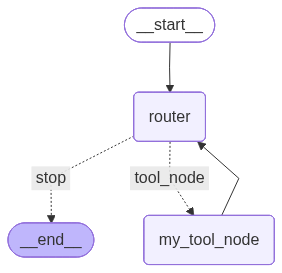

In [174]:
from IPython.display import Image, display

display(Image(react_agent.get_graph(xray=True).draw_mermaid_png()))

In [175]:
config = {"configurable": {"thread_id": "5"}}
messages = [HumanMessage(content="What is 2 times Brad Pitt's age?")]
messages = react_agent.invoke({"messages": messages}, config=config)

In [176]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times Brad Pitt's age?
================================== Ai Message ==================================
Tool Calls:
  search_tool (fc_beff358e-b7e2-44a3-b3bf-a4d7b15c5735)
 Call ID: fc_beff358e-b7e2-44a3-b3bf-a4d7b15c5735
  Args:
    query: Brad Pitt age
================================= Tool Message =================================

Brad Pitt marked his 62nd birthday on Thursday, Dec. 18 The actor is "doing well" and he's "excited" about his future with girlfriend Ines de Ramon, a source tells PEOPLE "She's perfect for him ... Brad Pitt arrived at a Los Angeles event on Tuesday with a much-younger girlfriend on his arm and a brand-new hairstyle on his head. The Oscar-winning actor, 62, attended the world premiere of a ... Brad Pitt Age Brad Pitt was born on 18 December 1963 in Shawnee, Oklahoma, United States. He is 62 years old as of 2025, and his zodiac sign is Sagittarius. Brad Pitt, 61, wa

In [179]:
react_agent.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content="What is 2 times Brad Pitt's age?", additional_kwargs={}, response_metadata={}, id='9ac0fdc2-7572-40c2-80cd-4174addf46ef'), AIMessage(content='', additional_kwargs={'reasoning_content': "We need to compute 2 * Brad Pitt's age. Need Brad Pitt's age. Use search tool.", 'tool_calls': [{'id': 'fc_beff358e-b7e2-44a3-b3bf-a4d7b15c5735', 'function': {'arguments': '{"query":"Brad Pitt age"}', 'name': 'search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 300, 'total_tokens': 352, 'completion_time': 0.111379785, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.012220122, 'prompt_tokens_details': None, 'queue_time': 0.004966145, 'total_time': 0.123599907}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e54bd-b36

In [181]:
for state in react_agent.get_state_history(config=config):
    print("State:", state)

State: StateSnapshot(values={'messages': [HumanMessage(content="What is 2 times Brad Pitt's age?", additional_kwargs={}, response_metadata={}, id='9ac0fdc2-7572-40c2-80cd-4174addf46ef'), AIMessage(content='', additional_kwargs={'reasoning_content': "We need to compute 2 * Brad Pitt's age. Need Brad Pitt's age. Use search tool.", 'tool_calls': [{'id': 'fc_beff358e-b7e2-44a3-b3bf-a4d7b15c5735', 'function': {'arguments': '{"query":"Brad Pitt age"}', 'name': 'search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 300, 'total_tokens': 352, 'completion_time': 0.111379785, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.012220122, 'prompt_tokens_details': None, 'queue_time': 0.004966145, 'total_time': 0.123599907}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5